In [42]:
import torch
import torch.nn as nn
from PIL import Image
import torchvision.transforms as transforms

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [44]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [45]:
class CatDogCNN(nn.Module):    
    def __init__(self):        
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),        
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128), nn.ReLU(),
            nn.Linear(128, 1),        
        )    
    def forward(self, x):                         
        return self.fc(self.cnn(x))
model = CatDogCNN().to(device)

In [58]:
import matplotlib.pyplot as plt


In [59]:
model = CatDogCNN().to(device)
model.load_state_dict(torch.load("catdog_best.pth", map_location=device))
model.eval()

def predict_img(img_path):
    raw_img = Image.open(img_path).convert("RGB")
    img = transform(raw_img)
    img = img.unsqueeze(0)
    img = img.to(device)

    with torch.no_grad():
        out = model(img)
    prob = torch.sigmoid(out).item()

    if prob > 0.5:
        pred_text = f"狗,概率: {prob:.4f}"
    else:
        pred_text = f"猫,概率: {1-prob:.4f}"

    # 绘图
    plt.figure()
    plt.imshow(raw_img)
    plt.axis("off")
    plt.title(pred_text)
    plt.show()

    return pred_text


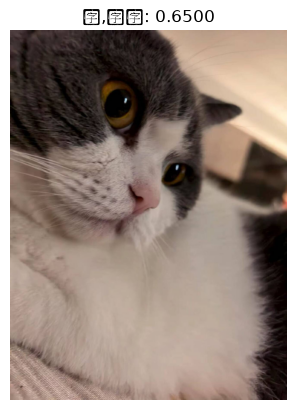

猫,概率: 0.6500


In [65]:
result = predict_img(r"C:\Users\癌坤\Desktop\11b34f1f2c7001e3ec099965ff3949ab_720.png")
print(result)
